# **Policy Assistant Using RAG & HuggingFace**

Built an AI-powered question-answering system designed to help employees instantly find answers from company policy documents. Instead of manually searching through pages of text, employees can simply type a question and get a clear, accurate answer in seconds.

To make this work, combined two powerful techniques — retrieval and generation. First, the system searches through the documents to find the most relevant paragraphs using Facebook's Dense Passage Retriever (DPR) and FAISS for fast similarity search. Then, it feeds those paragraphs into GPT-2, which generates a natural, readable answer based on the retrieved content.

Built the full pipeline from scratch — loading and preprocessing the documents, encoding them into vector embeddings, indexing them for fast search, and finally connecting everything to the GPT-2 generator. The result is a system that gives grounded, document-backed answers rather than relying on what the AI already knows, making it far more accurate and trustworthy for domain-specific use cases.

### **Import Libraries**


In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
from sklearn.manifold import TSNE
import torch
import faiss
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers import DPRContextEncoder, DPRContextEncoderTokenizer, DPRQuestionEncoder, DPRQuestionEncoderTokenizer
import wget

### Load Dataset 

In [2]:
file_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/6JDbUb_L3egv_eOkouY71A.txt'

In [3]:
filename = "d:/Projects/rag-policy-assistant/files/company_policies.txt"
wget.download(file_url, out = filename)


'd:/Projects/rag-policy-assistant/files/company_policies (1).txt'

##### Pre-process Data

In [4]:
def data_preprocess (filename):
    
    with open (filename, "r") as file:
        text = file.read()
    
    paragraphs = text.split('\n')
    
    paragraph_list = [para.strip() for para in paragraphs if len(para.strip())> 0]
    
    return paragraph_list

In [5]:
policy_list = data_preprocess(filename=filename)
sample_list = policy_list[0:3]

In [6]:
sample_list

['1.\tCode of Conduct',
 'Our Code of Conduct outlines the fundamental principles and ethical standards that guide every member of our organization. We are committed to maintaining a workplace that is built on integrity, respect, and accountability.',
 'Integrity: We hold ourselves to the highest ethical standards. This means acting honestly and transparently in all our interactions, whether with colleagues, clients, or the broader community. We respect and protect sensitive information, and we avoid conflicts of interest.']

## Building the Retriever: Encoding and Indexing

Computers can't understand raw text directly — they work with numbers. So the first step is converting each paragraph into a list of numbers called a **vector embedding**. These vectors capture the meaning of the text, making it possible to compare paragraphs and find the ones most relevant to a user's question.

In this section, we encode all the paragraphs into vector embeddings and store them in a **FAISS index** — a tool that lets us search through thousands of vectors very quickly to find the best matches for any given query.

## Encoding Texts into Embeddings

To encode the paragraphs, we use the **Dense Passage Retriever (DPR)** model, specifically its context encoder. DPR is built on top of BERT but trained differently — instead of handling general NLP tasks, it is trained specifically to retrieve relevant passages by learning which documents best match a given question. This makes it much better at capturing the kind of meaning that matters for search and retrieval, compared to using a general-purpose BERT model.

In [7]:
model_name = "facebook/dpr-ctx_encoder-single-nq-base"

In [8]:
# context tokenizer
context_tokenizer = DPRContextEncoderTokenizer.from_pretrained(model_name)

In [9]:
context_tokenizer

DPRContextEncoderTokenizer(name_or_path='facebook/dpr-ctx_encoder-single-nq-base', vocab_size=30522, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [10]:
sample_tokens = context_tokenizer(sample_list, return_tensors='pt', padding=True, truncation=True, max_length=256)
sample_tokens

{'input_ids': tensor([[  101,  1015,  1012,  3642,  1997,  6204,   102,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101,  2256,  3642,  1997,  6204, 22106,  1996,  8050,  6481,  1998,
         12962,  4781,  2008,  5009,  2296,  2266,  1997,  2256,  3029,  1012,
          2057,  2024,  5462,  2000,  8498,  1037, 16165,  2008,  2003,  2328,
          2006, 11109,  1010,  4847,  1010,  1998, 17842,  1012,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0],
        [  101, 11109,  1024,  2057,  2907,  9731,  2000,  1996,  3284, 12962,
          4781,  1012,  2023,  2965,  3772,  9826,  1998, 13338,  2135,  1999,
          2035,  2256, 10266,  1010,

In [11]:
for text in sample_tokens.input_ids:
    output_text = context_tokenizer.convert_ids_to_tokens(text)
    print(output_text)

['[CLS]', '1', '.', 'code', 'of', 'conduct', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'our', 'code', 'of', 'conduct', 'outlines', 'the', 'fundamental', 'principles', 'and', 'ethical', 'standards', 'that', 'guide', 'every', 'member', 'of', 'our', 'organization', '.', 'we', 'are', 'committed', 'to', 'maintaining', 'a', 'workplace', 'that', 'is', 'built', 'on', 'integrity', ',', 'respect', ',', 'and', 'accountability', '.', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
['[CLS]', 'integrity', ':', 'we', 'hold', 'ourselves', 'to', 'the', 'highest', 'ethical', 'standards',

### Context Embedding
**2. Encoding**: Once the text is tokenized, it is passed into the `context_encoder`. The model reads through the tokens and compresses the entire meaning of the text into a single dense vector — think of it as a compact numerical summary that captures what the paragraph is really about.

The `DPRContextEncoder` is built on the same foundation as BERT but trained for a different purpose. While BERT is a general-purpose language model designed to handle a wide range of NLP tasks, DPR is trained specifically to match questions with relevant passages. It learns this through **contrastive learning** — a training approach where the model is taught to pull relevant question-passage pairs closer together in vector space and push unrelated ones further apart. This makes DPR far more effective at retrieval tasks than a standard BERT model.

In [12]:
context_encoder = DPRContextEncoder.from_pretrained(model_name)
context_encoder

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] DPRContextEncoder LOAD REPORT from: facebook/dpr-ctx_encoder-single-nq-base
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
ctx_encoder.bert_model.pooler.dense.bias   | UNEXPECTED |  | 
ctx_encoder.bert_model.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DPRContextEncoder(
  (ctx_encoder): DPREncoder(
    (bert_model): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=768, bia

In [13]:
# shuffle samples
random.seed = 42
random.shuffle(policy_list)
random.shuffle(sample_list)

In [14]:
output_sample = context_encoder(**sample_tokens)
output_sample

DPRContextEncoderOutput(pooler_output=tensor([[ 0.9058,  0.1277, -0.0524,  ..., -0.3109, -0.0634,  0.1343],
        [ 0.8406,  0.6897,  0.0202,  ..., -0.4066,  0.0511,  0.3425],
        [ 0.8745,  0.6094, -0.1193,  ..., -0.0681, -0.1915,  0.0144]],
       grad_fn=<SelectBackward0>), hidden_states=None, attentions=None)

In [15]:
output_sample.pooler_output, output_sample.pooler_output.shape

(tensor([[ 0.9058,  0.1277, -0.0524,  ..., -0.3109, -0.0634,  0.1343],
         [ 0.8406,  0.6897,  0.0202,  ..., -0.4066,  0.0511,  0.3425],
         [ 0.8745,  0.6094, -0.1193,  ..., -0.0681, -0.1915,  0.0144]],
        grad_fn=<SelectBackward0>),
 torch.Size([3, 768]))

### **Context Embedding Function**

In [16]:
def context_embeddings(text_list):
    embeddings = []
    for text in text_list:
        tokens = context_tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=256)
        output_embeddings = context_encoder(**tokens)
        outputs = output_embeddings.pooler_output
        
        embeddings.append(outputs)
    return torch.cat(embeddings).detach().numpy()
    

In [17]:
policy_embeddings = context_embeddings(policy_list)
policy_embeddings

array([[ 0.69751954,  0.5583451 ,  0.19171847, ..., -0.6279446 ,
        -0.48371553, -0.1460331 ],
       [ 0.17804609,  0.5351761 ,  0.55847096, ..., -0.60847646,
        -0.83044916, -0.17659123],
       [ 0.7579645 ,  0.5367609 ,  0.06447412, ..., -0.32965466,
        -0.06132501,  0.35504448],
       ...,
       [ 0.5982949 ,  0.3699832 ,  0.6133506 , ..., -0.29540408,
        -0.47808248,  0.32521054],
       [ 0.22137795,  0.3090461 , -0.35354418, ..., -0.45853198,
        -0.9006421 , -0.1875049 ],
       [ 0.4388053 ,  0.11872505,  0.07763551, ..., -0.41570365,
        -0.58364624, -0.07130975]], shape=(76, 768), dtype=float32)

##### Plot the T-Sne Distribution

In [18]:
def plot_tsne(data):
    
    tsne = TSNE(n_components=3, perplexity=data.shape[0]-1, random_state=42)
    data_3d = tsne.fit_transform(data)
    
    #plot the graphs
    fig= plt.figure(figsize=(10,10))
    ax = fig.add_subplot(111, projection='3d')
    
    #assign color for each data points based on thier index
    num_points = len(data_3d)
    colors = plt.cm.tab20(np.linspace(0,1,num_points))
    
    for idx, point in enumerate(data_3d):
        ax.scatter(point[0], point[1], point[2], label = str(idx), color = colors[idx])
    
    ax.set_xlabel('TSNE Component 1')
    ax.set_ylabel('TSNE Component 2')
    ax.set_zlabel('TSNE Component 3')
    plt.title('3D t-SNE Visualization')
    plt.legend(title='Input Order')
    plt.show()    

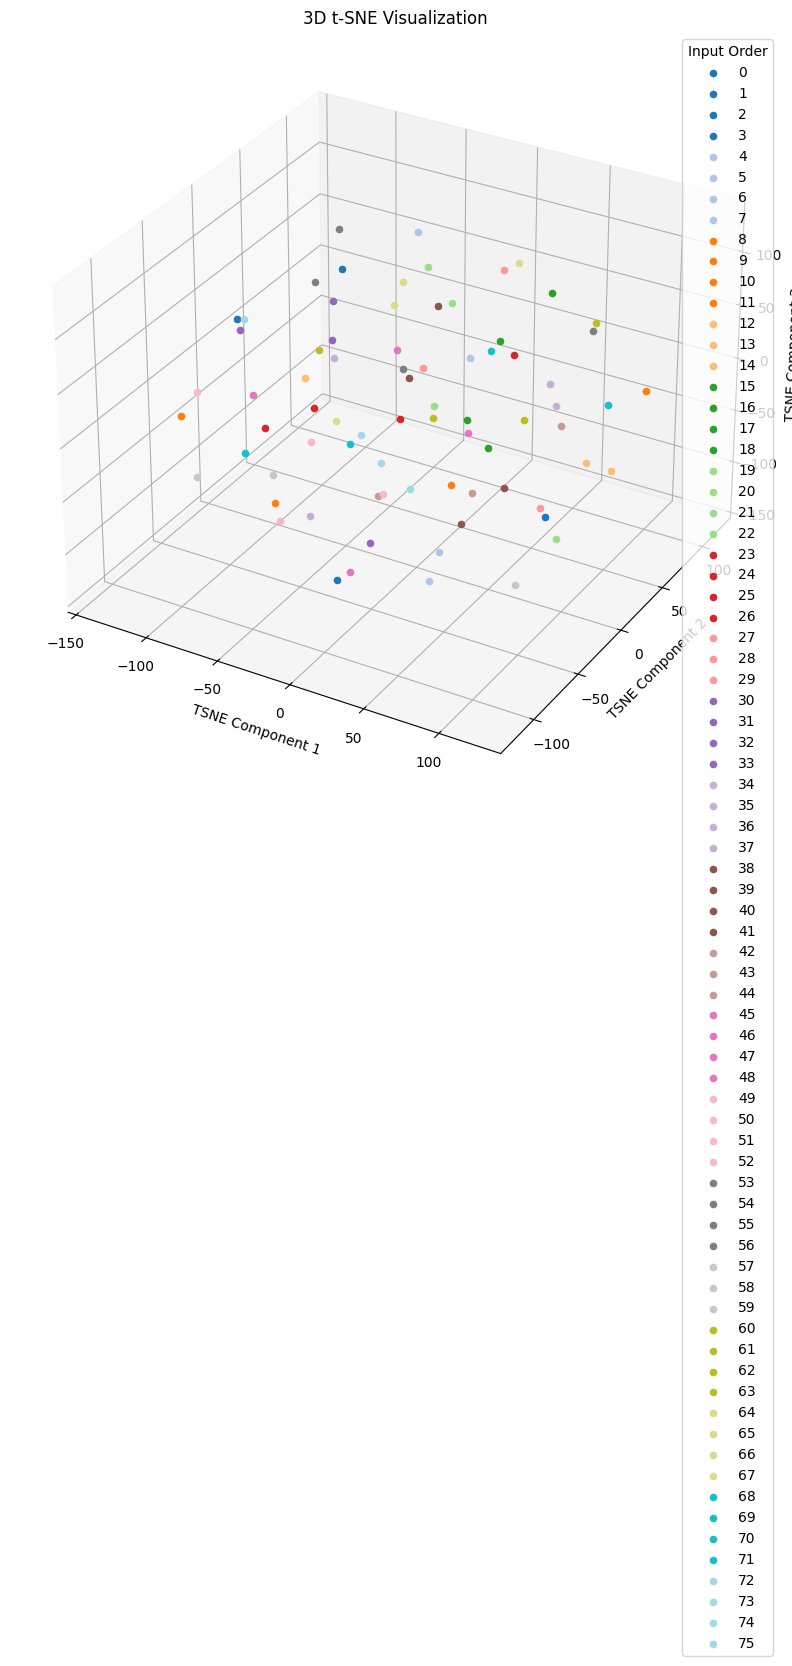

In [19]:
plot_tsne(policy_embeddings)

### **FAISS Implementation**

## Creating and Populating the FAISS Index

Once text paragraphs are transformed into dense vector embeddings, the next key step is to build and populate a FAISS index. FAISS (Facebook AI Similarity Search) is a high-performance library developed by Facebook for efficient similarity search and clustering of vector embeddings.

---

### Overview of FAISS

- **High efficiency**: FAISS is optimized for fast similarity search, making it highly effective when working with large-scale datasets. It is commonly used in NLP applications where quick retrieval of relevant information is important.  
- **Scalability**: It can manage very large datasets while maintaining strong performance, which makes it suitable for production-level retrieval systems.

---

### Using IndexFlatL2

- **Index type**: `IndexFlatL2` is a simple yet widely used FAISS index. It calculates similarity using the Euclidean distance (L2 norm) between vectors to identify how close they are in vector space. While straightforward, it provides accurate results for many retrieval tasks.  
- **Use case**: This index is ideal for retrieval systems where the objective is to find the most semantically similar documents or pieces of information based on their vector embeddings.

In [20]:
dims = policy_embeddings.shape[1]
dims

768

In [21]:
index = faiss.IndexFlatL2(dims)
#Before add policy embeddings it should convert into numpy arrays
policy_embeddings = np.array(policy_embeddings, dtype=np.float32)
index.add(policy_embeddings)

### **DPR-Question Embeddings(Query Embeddings)**

**We need to implement seperate embeddings and tokenizers for query and the context.**

In [22]:
query_tokenizer = DPRQuestionEncoderTokenizer.from_pretrained(model_name)
query_tokenizer

DPRQuestionEncoderTokenizer(name_or_path='facebook/dpr-ctx_encoder-single-nq-base', vocab_size=30522, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

In [23]:
query_encoder = DPRQuestionEncoder.from_pretrained(model_name)
query_encoder

Loading weights: 0it [00:00, ?it/s]

[transformers] DPRQuestionEncoder LOAD REPORT from: facebook/dpr-ctx_encoder-single-nq-base
Key                                                                                  | Status     | 
-------------------------------------------------------------------------------------+------------+-
ctx_encoder.bert_model.encoder.layer.{0...11}.attention.self.key.bias                | UNEXPECTED | 
ctx_encoder.bert_model.encoder.layer.{0...11}.output.dense.weight                    | UNEXPECTED | 
ctx_encoder.bert_model.encoder.layer.{0...11}.attention.self.value.bias              | UNEXPECTED | 
ctx_encoder.bert_model.embeddings.token_type_embeddings.weight                       | UNEXPECTED | 
ctx_encoder.bert_model.encoder.layer.{0...11}.attention.self.value.weight            | UNEXPECTED | 
ctx_encoder.bert_model.encoder.layer.{0...11}.output.LayerNorm.weight                | UNEXPECTED | 
ctx_encoder.bert_model.pooler.dense.bias                                             | UNEXPECTED | 

DPRQuestionEncoder(
  (question_encoder): DPREncoder(
    (bert_model): BertModel(
      (embeddings): BertEmbeddings(
        (word_embeddings): Embedding(30522, 768, padding_idx=0)
        (position_embeddings): Embedding(512, 768)
        (token_type_embeddings): Embedding(2, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): BertEncoder(
        (layer): ModuleList(
          (0-11): 12 x BertLayer(
            (attention): BertAttention(
              (self): BertSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): BertSelfOutput(
                (dense): Linear(in_features=768, out_features=76

#### Query and Context Retrieval

In this section demonstrates how the system handles a sample query and retrieves the most relevant information from the indexed dataset. This example highlights how all components work together to complete a full retrieval process.

To begin, the input query is first converted from raw text into a format compatible with the DPR question encoder. It is then transformed into a dense vector representation. Using this query embedding, the FAISS index is searched to identify the most relevant context passages based on similarity.

Once the search is performed using the query vector, the output consists of two main elements:

- **D (Distances)**: This array represents the similarity scores (or distances) between the query embedding and each of the retrieved document embeddings. Smaller distance values indicate a closer match and therefore higher relevance to the query.

- **I (Indices)**: This array contains the positions of the most relevant paragraphs within the original `paragraphs` dataset. These indices map directly to the source text, allowing easy access to the corresponding content.

Together, `D` and `I` provide both:
- a numerical measure of relevance, and  
- the actual retrieved text locations  

This combination enables accurate and efficient retrieval of context relevant to the user’s query.

In [24]:
question = "Drug and Alcohol Policy"

In [25]:
question_tokens = query_tokenizer(question, return_tensors='pt')
ques_embeddings = query_encoder(**question_tokens)
#we need to convert tensors into numpy arrays

ques_embeddings = ques_embeddings.pooler_output.detach().numpy()

#### **FAISS Search**

In [26]:
D,I = index.search(ques_embeddings,k=5)
print(f"Distances:{D}")
print(f"Indices:{I}")

Distances:[[868.0979  869.41925 869.8511  872.8835  874.50305]]
Indices:[[ 8 72 40 47 73]]


In [27]:
print("Top 5 relevant contexts:")
for i, ids in enumerate(I[0]):
    print(f"{i+1}: {policy_list[ids]}")
    print(f"Distance: {D[0][i]}\n")

Top 5 relevant contexts:
1: Employee Referrals: We encourage and appreciate employee referrals as they contribute to building a strong and engaged team.
Distance: 868.097900390625

2: Onboarding: New employees receive comprehensive onboarding to help them integrate into the organization effectively. This includes information on our culture, policies, and expectations.
Distance: 869.4192504882812

3: The Mobile Phone Policy sets forth the standards and expectations governing the appropriate and responsible usage of mobile devices in the organization. The purpose of this policy is to ensure that employees utilize mobile phones in a manner consistent with company values and legal compliance.
Distance: 869.85107421875

4: Monitoring: The company retains the right to monitor internet and email usage for security and compliance purposes.
Distance: 872.8834838867188

5: The Mobile Phone Policy is aimed at promoting the responsible and secure use of mobile devices in line with legal and ethica

In [28]:
def faiss_search(question):
    
    ques_tokens = query_tokenizer(question,return_tensors='pt')
    ques_embeds = query_encoder(**ques_tokens).pooler_output.detach().numpy()
    
    D,I = index.search(ques_embeds, k=5)
    
    return D, I

### Enhance the Output

**We get involve with the GPT model to generate more descriptive response more align with the query and the context combination**

In [29]:
model = AutoModelForCausalLM.from_pretrained("openai-community/gpt2")
tokenizer = AutoTokenizer.from_pretrained("openai-community/gpt2")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [30]:
def reponse_with_context (question, context, model:AutoModelForCausalLM):
    
    input_text = question + " "+ " ".join(context)
    input_tokens = tokenizer(input_text, return_tensors='pt', max_length=1024, truncation=True)
    
    response = model.generate(input_tokens['input_ids'], max_new_tokens = 70, min_length = 40,
                              length_penalty = 2.0, num_beams = 4, early_stopping = True,
                              pad_token_id = tokenizer.eos_token_id)
    
    return tokenizer.decode(response[0], skip_special_tokens=True)

In [31]:
question = "what is mobile policy?"

In [32]:
D, I = faiss_search(question)
top_context = [policy_list[i] for i in I[0]]

**GPT response for question**

In [33]:
reponse_with_context(question,top_context,model)

[transformers] The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


'what is mobile policy? The Mobile Phone Policy sets forth the standards and expectations governing the appropriate and responsible usage of mobile devices in the organization. The purpose of this policy is to ensure that employees utilize mobile phones in a manner consistent with company values and legal compliance. Employee Referrals: We encourage and appreciate employee referrals as they contribute to building a strong and engaged team. 9.\tDiscipline and Termination Policy Onboarding: New employees receive comprehensive onboarding to help them integrate into the organization effectively. This includes information on our culture, policies, and expectations. 2.\tRecruitment Policy Onboarding: New employees receive comprehensive onboarding to help them integrate into the organization effectively. This includes information on our culture, policies, and expectations. Employee Referrals: We encourage and appreciate employee referrals as they contribute to building a strong and engaged te